In [4]:
import pandas as pd

df = pd.read_csv("../data/raw_reviews.csv")

print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

df.head()

Dataset Shape:
(4915, 12)

Column Names:
['Unnamed: 0', 'reviewerName', 'overall', 'reviewText', 'reviewTime', 'day_diff', 'helpful_yes', 'helpful_no', 'total_vote', 'score_pos_neg_diff', 'score_average_rating', 'wilson_lower_bound']


,Unnamed: 0,reviewerName,overall,reviewText,reviewTime,day_diff,helpful_yes,helpful_no,total_vote,score_pos_neg_diff,score_average_rating,wilson_lower_bound
0,0,NaN,4.0,No issues.,2014-07-23,138,0,0,0,0,0.0,0.0
1,1,0mie,5.0,"Purchased this for my device, it worked as adv...",2013-10-25,409,0,0,0,0,0.0,0.0
2,2,1K3,4.0,it works as expected. I should have sprung for...,2012-12-23,715,0,0,0,0,0.0,0.0
3,3,1m2,5.0,This think has worked out great.Had a diff. br...,2013-11-21,382,0,0,0,0,0.0,0.0
4,4,2&amp;1/2Men,5.0,"Bought it with Retail Packaging, arrived legit...",2013-07-13,513,0,0,0,0,0.0,0.0


In [5]:
for col in df.columns:
    print(col)

Unnamed: 0
reviewerName
overall
reviewText
reviewTime
day_diff
helpful_yes
helpful_no
total_vote
score_pos_neg_diff
score_average_rating
wilson_lower_bound


DATASET SHAPE
(4915, 12)

COLUMN NAMES
['Unnamed: 0', 'reviewerName', 'overall', 'reviewText', 'reviewTime', 'day_diff', 'helpful_yes', 'helpful_no', 'total_vote', 'score_pos_neg_diff', 'score_average_rating', 'wilson_lower_bound']

MISSING VALUES
Unnamed: 0              0
reviewerName            1
overall                 0
reviewText              1
reviewTime              0
day_diff                0
helpful_yes             0
helpful_no              0
total_vote              0
score_pos_neg_diff      0
score_average_rating    0
wilson_lower_bound      0
dtype: int64

DATA TYPES
Unnamed: 0                int64
reviewerName                str
overall                 float64
reviewText                  str
reviewTime                  str
day_diff                  int64
helpful_yes               int64
helpful_no                int64
total_vote                int64
score_pos_neg_diff        int64
score_average_rating    float64
wilson_lower_bound      float64
dtype: object

RATING DISTRIBUT

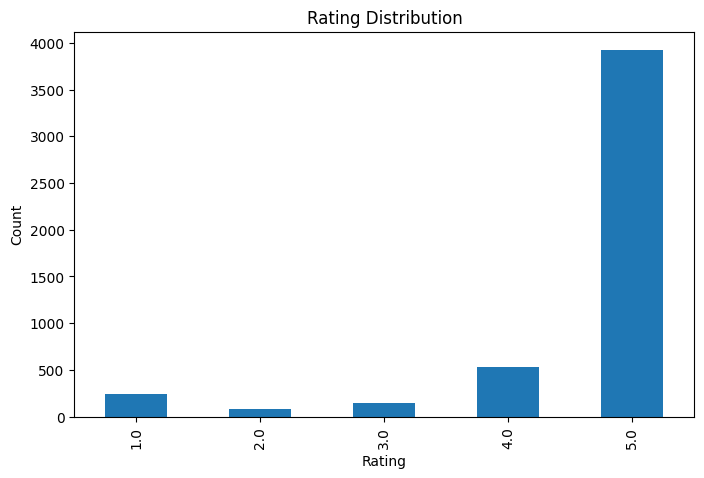

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

print("="*60)
print("DATASET SHAPE")
print("="*60)
print(df.shape)

print("\n" + "="*60)
print("COLUMN NAMES")
print("="*60)
print(df.columns.tolist())

print("\n" + "="*60)
print("MISSING VALUES")
print("="*60)
print(df.isnull().sum())

print("\n" + "="*60)
print("DATA TYPES")
print("="*60)
print(df.dtypes)

print("\n" + "="*60)
print("RATING DISTRIBUTION")
print("="*60)
print(df["overall"].value_counts().sort_index())

print("\n" + "="*60)
print("DUPLICATE REVIEWS")
print("="*60)
print(df["reviewText"].duplicated().sum())

print("\n" + "="*60)
print("AVERAGE RATING")
print("="*60)
print(round(df["overall"].mean(), 2))

print("\n" + "="*60)
print("SAMPLE REVIEWS")
print("="*60)
print(df[["reviewText", "overall"]].head())

# Rating Distribution Plot
plt.figure(figsize=(8,5))
df["overall"].value_counts().sort_index().plot(kind="bar")
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

In [8]:
def create_sentiment(rating):
    if rating <= 2:
        return "Negative"
    elif rating == 3:
        return "Neutral"
    else:
        return "Positive"

df["Sentiment"] = df["overall"].apply(create_sentiment)

print(df["Sentiment"].value_counts())

Sentiment
Positive    4449
Negative     324
Neutral      142
Name: count, dtype: int64


In [9]:
working_df = df[
    [
        "reviewText",
        "overall",
        "reviewTime",
        "Sentiment"
    ]
]

working_df.to_csv(
    "../data/cleaned_reviews.csv",
    index=False
)

print("Saved Successfully")
print(working_df.shape)


Saved Successfully
(4915, 4)


In [10]:
import pandas as pd

def load_data(path):
    return pd.read_csv(path)

def remove_nulls(df):
    return df.dropna()

def remove_duplicates(df):
    return df.drop_duplicates()

def clean_data(df):
    df = remove_nulls(df)
    df = remove_duplicates(df)
    return df

if __name__ == "__main__":
    df = load_data("../data/cleaned_reviews.csv")

    print("Before Cleaning:", df.shape)

    df = clean_data(df)

    print("After Cleaning:", df.shape)

Before Cleaning: (4915, 4)
After Cleaning: (4914, 4)
